A.1 - Exploratory Data Analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Data Loading and Basic Plot

In [3]:
df = pd.read_csv("turtle-2.csv")
df.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


<function matplotlib.pyplot.show(close=None, block=None)>

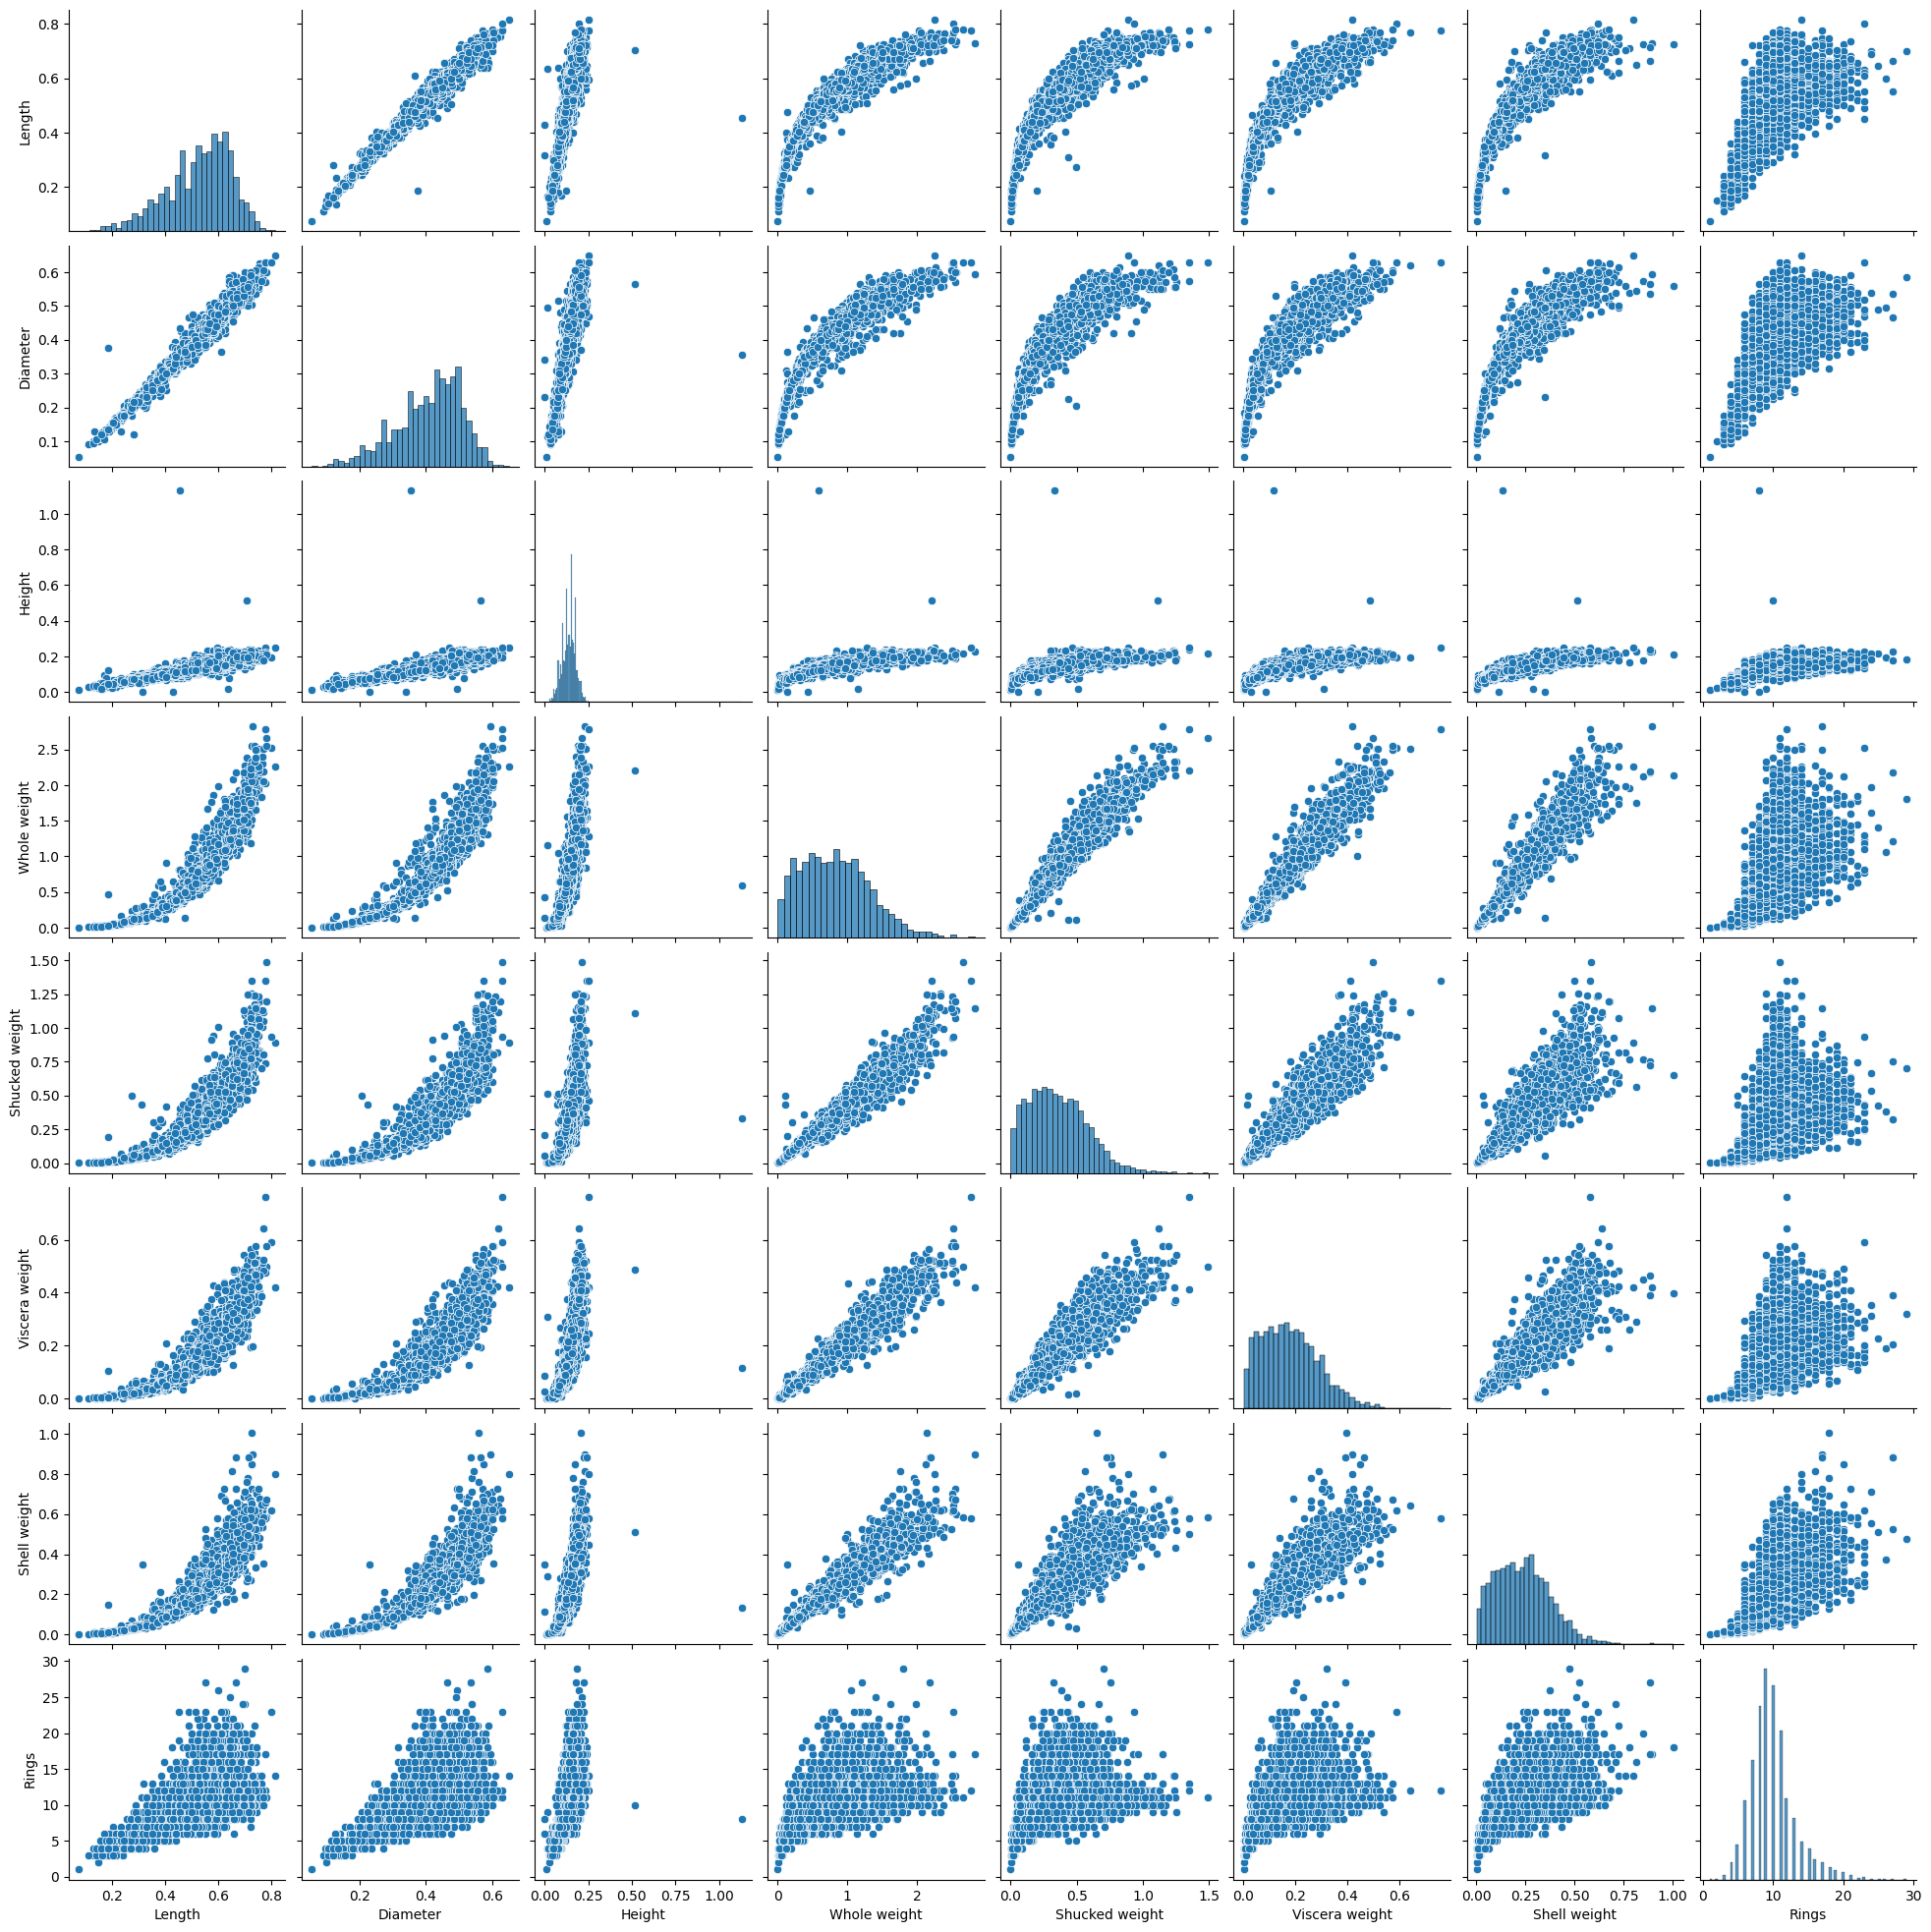

In [4]:
sns.pairplot(df)
plt.show

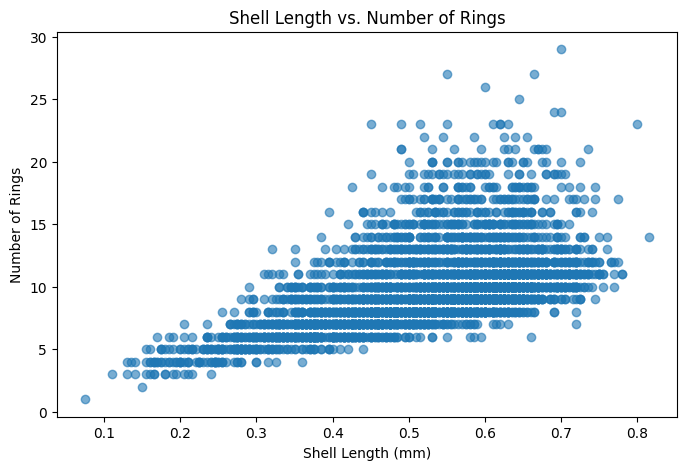

In [5]:
plt.figure(figsize=(8,5))
plt.scatter(df["Length"], df["Rings"], alpha = 0.6)
plt.xlabel("Shell Length (mm)")
plt.ylabel("Number of Rings")
plt.title("Shell Length vs. Number of Rings")
plt.show()

Summary Statistics and Correlations

In [6]:
df.describe()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


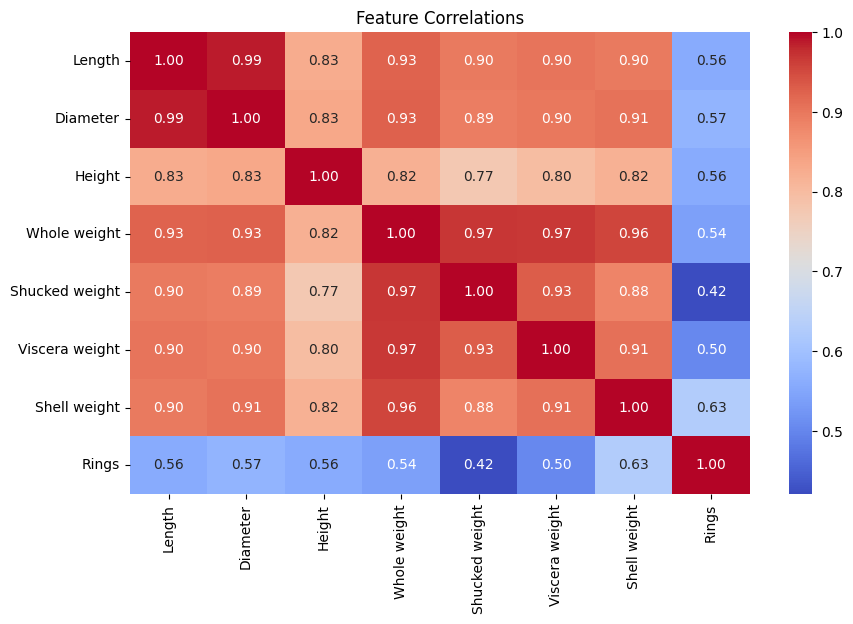

In [7]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include = ["number"]).corr(), annot=True, cmap="coolwarm", fmt= ".2f")
plt.title("Feature Correlations")
plt.show()

- Shell weight correlates most strongly with Rings with a correlation value of 0.63.

Categorical Influence (Gender)

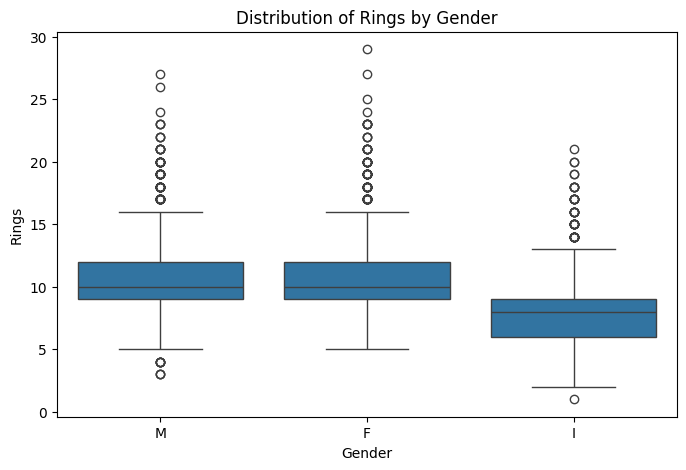

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Sex"], y=df["Rings"])
plt.xlabel("Gender")
plt.ylabel("Rings")
plt.title("Distribution of Rings by Gender")
plt.show()

Males (M) and Females (F) have similar distributions, with median ring counts appearing slightly higher than that of Immatures (I). Immature turtles (I) tend to have a lower median number of rings and a slightly narrower range, which makes sense as younger turtles are more likely to fall into this category.

A.2 - Regression Tasks

In [9]:
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor
import matplotlib.pyplot as plt 
import numpy as np

Encoding sex column and defining the features

In [10]:
df_encoded = pd.get_dummies(df, columns =["Sex"], drop_first=True)

X = df_encoded.drop(columns=["Rings"]) 
y = df_encoded["Rings"] 

Train-Val-Test Split 


- Manualy bining Rings 

In [11]:
#y.value_counts().sort_index()
bin_edges = [1, 5, 10, 15, 20, max(y)] 
y_binned = np.digitize(y, bins=bin_edges, right=True)

#check dis
#pd.Series(y_binned).value_counts().sort_index()

y_binned[y_binned == 0] = 1 
y_binned[y_binned == 5] = 4 

pd.Series(y_binned).value_counts().sort_index()

1     189
2    2541
3    1186
4     261
Name: count, dtype: int64

- Spliting 80 - 20 and then the 20 into 10 - 10
- Standardizing numerical features
- Converting back into the data frame

In [12]:
strat_split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, temp_idx = next(strat_split.split(X, y_binned))

X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
X_temp, y_temp = X.iloc[temp_idx], y.iloc[temp_idx]
y_temp_binned = y_binned[temp_idx]

strat_split_2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(strat_split_2.split(X_temp, y_temp_binned))

X_val, y_val = X_temp.iloc[val_idx], y_temp.iloc[val_idx]
X_test, y_test = X_temp.iloc[test_idx], y_temp.iloc[test_idx]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


X_train = pd.DataFrame(X_train_scaled, columns=X.columns)
X_val = pd.DataFrame(X_val_scaled, columns=X.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X.columns)

X_train.shape, X_val.shape, X_test.shape

((3341, 9), (418, 9), (418, 9))

Linear Regression

- Training the linear model and making predictions on the test set

In [13]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

r2, mse, mae

(0.4744290340827111, 5.5210639798693, 1.6654609114584749)

Brief comment: 
- decent performance but not perfect, there is still significant variance in rings that the model doesnt capture 
- since r2 is only 47.4%, the linear relatationship  might not be strong enough 


Polynomial Regression 

- Looping over Polynomial degrees 
- Evaluating on validation set 
- Finding best degree

In [26]:
results = {}

for degree in range(2,6):
    
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)

    poly_reg = LinearRegression()
    poly_reg.fit(X_train_poly, y_train)

    y_val_pred = poly_reg.predict(X_val_poly)

    r2 = r2_score(y_val, y_val_pred)
    mse = mean_squared_error(y_val, y_val_pred)
    mae = mean_absolute_error(y_val, y_val_pred)

    results[degree] = {"r2": r2, "mse": mse, "mae": mae}

best_degree = max(results, key=lambda d: results[d]["r2"])
print("best degree is:", best_degree)
print("these were the results:", results)

best degree is: 2
these were the results: {2: {'r2': 0.5618575091378043, 'mse': 4.205901100842887, 'mae': 1.5004368996790063}, 3: {'r2': 0.3894760138457052, 'mse': 5.860658482139683, 'mae': 1.6346665679530938}, 4: {'r2': -0.5891942287647713, 'mse': 15.255296839760653, 'mae': 2.004671418679135}, 5: {'r2': -1004.5764242757779, 'mse': 9652.921316808239, 'mae': 14.333078580342415}}


- Evaluating best degree on test set

In [27]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)  
X_test_poly = poly.transform(X_test)  

best_poly_reg = LinearRegression()
best_poly_reg.fit(X_train_poly, y_train)

y_test_pred = best_poly_reg.predict(X_test_poly)

r2_test = r2_score(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

r2_test, mse_test, mae_test

(0.5158730771411209, 5.085698961349711, 1.581193479185244)

conclusion
- the higher degrees overfitted badly


KNN

- Looping over k
- Evaluating on validation set 
- Finding best k


In [31]:
knn_results = {}

for k in [1, 3, 6, 10]:
    
    knn_reg= KNeighborsRegressor(n_neighbors=k)
    knn_reg.fit(X_train, y_train)

    y_val_pred = knn_reg.predict(X_val)

    r2 = r2_score(y_val, y_val_pred)
    mse = mean_squared_error(y_val, y_val_pred)
    mae = mean_absolute_error(y_val, y_val_pred)

    knn_results[k] = {"r2": r2, "mse": mse, "mae": mae}

best_k = max(knn_results, key=lambda k: knn_results[k]["r2"])
print("best k is:", best_k)
print("these were the results:", knn_results)

best k is: 10
these were the results: {1: {'r2': 0.1763333182291903, 'mse': 7.9066985645933014, 'mae': 1.9545454545454546}, 3: {'r2': 0.4359911590415917, 'mse': 5.414141414141414, 'mae': 1.6698564593301435}, 6: {'r2': 0.5081329517019852, 'mse': 4.72162413609782, 'mae': 1.5602073365231262}, 10: {'r2': 0.5320626217771535, 'mse': 4.491913875598087, 'mae': 1.5210526315789472}}


- Evaluating best k on test set 

In [30]:
best_knn_reg = KNeighborsRegressor(n_neighbors=best_k)
best_knn_reg.fit(X_train, y_train)

y_test_pred = best_knn_reg.predict(X_test)

r2_test_knn = r2_score(y_test, y_test_pred)
mse_test_knn = mean_squared_error(y_test, y_test_pred)
mae_test_knn = mean_absolute_error(y_test, y_test_pred)

r2_test_knn, mse_test_knn, mae_test_knn

(0.5082170752118274, 5.166124401913877, 1.576555023923445)

conclusion
- r2 score better than lower k values 
- mse lower error than smaller k values 
- mae lowest among all 

overal polynomal slightly better but k-10 is decent

<function matplotlib.pyplot.show(close=None, block=None)>

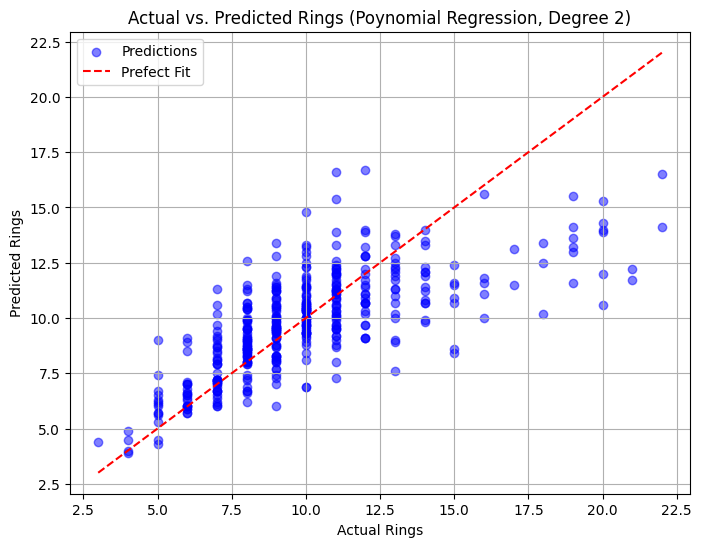

In [32]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha = 0.5, label = "Predictions", color="blue")

plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle= "--", color="red", label= "Prefect Fit")

plt.xlabel("Actual Rings")
plt.ylabel("Predicted Rings")
plt.title("Actual vs. Predicted Rings (Poynomial Regression, Degree 2)")
plt.legend()
plt.grid(True)

plt.show

analysis 
- model follows the trend but some points deviate indicatin prediction errors 
- predictions are better for midrange values but some extremes are off

B.2 - Fold-by-Fold Performance & Feature Importance

In [33]:
from sklearn.model_selection import cross_val_score, KFold

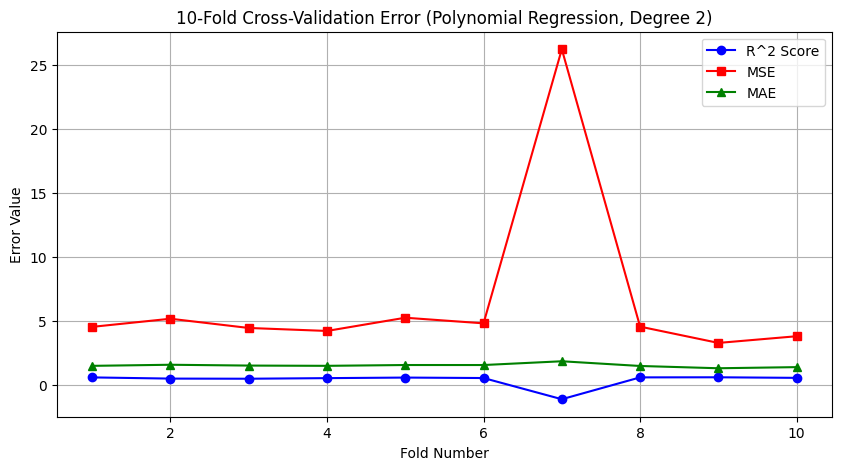

(np.float64(0.3911923129481127),
 np.float64(6.638013419418115),
 np.float64(1.5282303703780902))

In [34]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
poly_reg = LinearRegression()

kf = KFold(n_splits=10, shuffle=True, random_state=42)

r2_scores = cross_val_score(poly_reg, X_poly, y, cv=kf, scoring="r2")
mse_scores = -cross_val_score(poly_reg, X_poly, y, cv=kf, scoring="neg_mean_squared_error")
mae_scores = -cross_val_score(poly_reg, X_poly, y, cv=kf, scoring="neg_mean_absolute_error")

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), r2_scores, marker="o", label= "R^2 Score", color="blue")
plt.plot(range(1, 11), mse_scores, marker="s", label= "MSE", color="red")
plt.plot(range(1, 11), mae_scores, marker="^", label= "MAE", color="green")

plt.xlabel("Fold Number")
plt.ylabel("Error Value")
plt.title("10-Fold Cross-Validation Error (Polynomial Regression, Degree 2)")
plt.legend()
plt.grid(True)
plt.show()

r2_scores.mean(), mse_scores.mean(), mae_scores.mean()

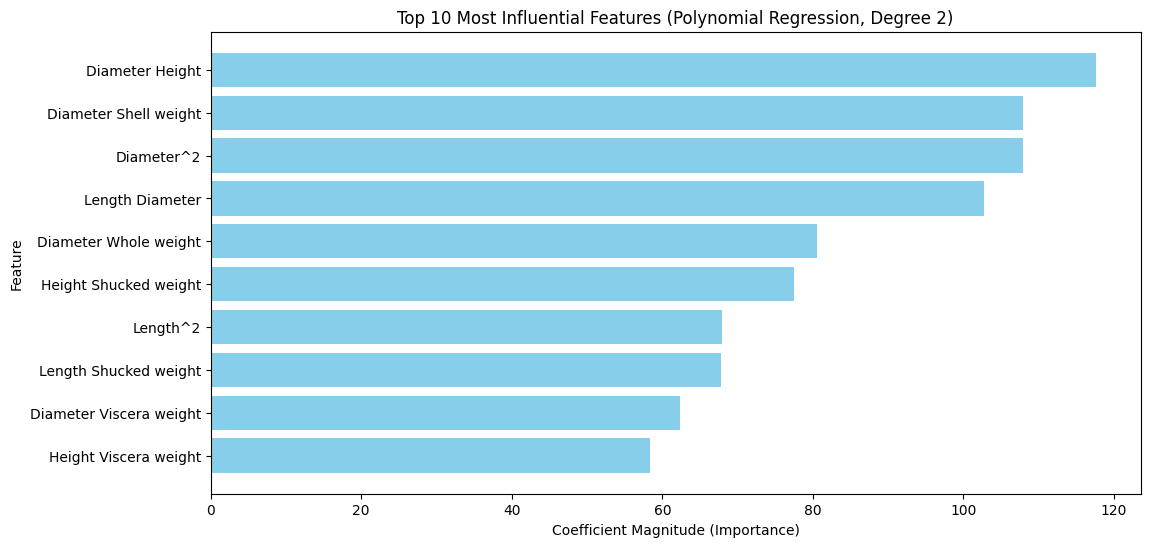

[('Diameter Height', np.float64(117.6576482595153)),
 ('Diameter Shell weight', np.float64(107.93083547967058)),
 ('Diameter^2', np.float64(107.8833283106733)),
 ('Length Diameter', np.float64(102.76868538479944)),
 ('Diameter Whole weight', np.float64(80.55620946662994)),
 ('Height Shucked weight', np.float64(77.54756895257623)),
 ('Length^2', np.float64(67.95564773316865)),
 ('Length Shucked weight', np.float64(67.78305761920672)),
 ('Diameter Viscera weight', np.float64(62.36065337851385)),
 ('Height Viscera weight', np.float64(58.3200748781565))]

In [38]:
import numpy as np

best_fold_idx = np.argmin(mse_scores)

kf_splits = list(kf.split(X_poly))  
train_idx, test_idx = kf_splits[best_fold_idx]

X_train_fold, X_test_fold = X_poly[train_idx], X_poly[test_idx]
y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]

best_fold_model = LinearRegression()
best_fold_model.fit(X_train_fold, y_train_fold)

feature_importance = np.abs(best_fold_model.coef_)
feature_names = poly.get_feature_names_out(X.columns) 

sorted_idx = np.argsort(feature_importance)[::-1]
sorted_features = [feature_names[i] for i in sorted_idx]
sorted_importance = feature_importance[sorted_idx]

plt.figure(figsize=(12, 6))
plt.barh(sorted_features[:10], sorted_importance[:10], color='skyblue')  
plt.xlabel("Coefficient Magnitude (Importance)")
plt.ylabel("Feature")
plt.title("Top 10 Most Influential Features (Polynomial Regression, Degree 2)")
plt.gca().invert_yaxis()  
plt.show()

list(zip(sorted_features[:10], sorted_importance[:10]))


In [39]:
mse_scores = []
mae_scores = []

for train_idx, val_idx in kf.split(X_poly):
    X_train, X_val = X_poly[train_idx], X_poly[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_val_pred = model.predict(X_val)
    
    mse = np.mean((y_val - y_val_pred) ** 2)
    mae = np.mean(np.abs(y_val - y_val_pred))
    
    mse_scores.append(mse)
    mae_scores.append(mae)

worst_fold_idx_mse = np.argmax(mse_scores)  # fold with highest MSE
worst_fold_idx_mae = np.argmax(mae_scores)  # fold with highest MAE


worst_mse = mse_scores[worst_fold_idx_mse]
worst_mae = mae_scores[worst_fold_idx_mae]

worst_fold_idx_mse + 1, worst_mse, worst_fold_idx_mae + 1, worst_mae


(np.int64(7),
 np.float64(26.234058711238717),
 np.int64(7),
 np.float64(1.8565537880306726))

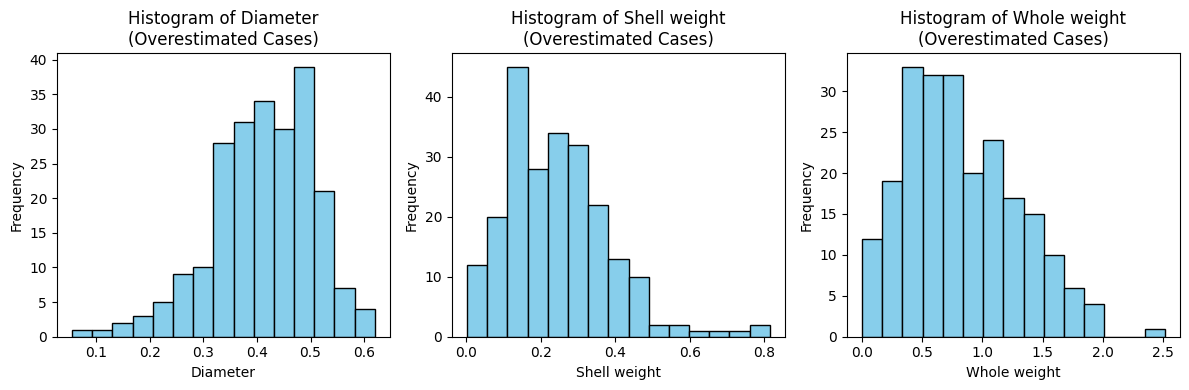

In [40]:

train_idx, val_idx = list(kf.split(X_poly))[worst_fold_idx_mse]

X_train_fold, X_val_fold = X_poly[train_idx], X_poly[val_idx]
y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

worst_fold_model = LinearRegression()
worst_fold_model.fit(X_train_fold, y_train_fold)

y_val_pred_fold = worst_fold_model.predict(X_val_fold)

overestimated_cases = (y_val_pred_fold > y_val_fold).values

X_val_df = pd.DataFrame(X_val_fold, columns=poly.get_feature_names_out(X.columns))
X_overestimated = X_val_df[overestimated_cases]

features_to_plot = ["Diameter", "Shell weight", "Whole weight"]

plt.figure(figsize=(12, 4))
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(1, 3, i)
    plt.hist(X_overestimated[feature], bins=15, color="skyblue", edgecolor="black")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.title(f"Histogram of {feature}\n(Overestimated Cases)")

plt.tight_layout()
plt.show()


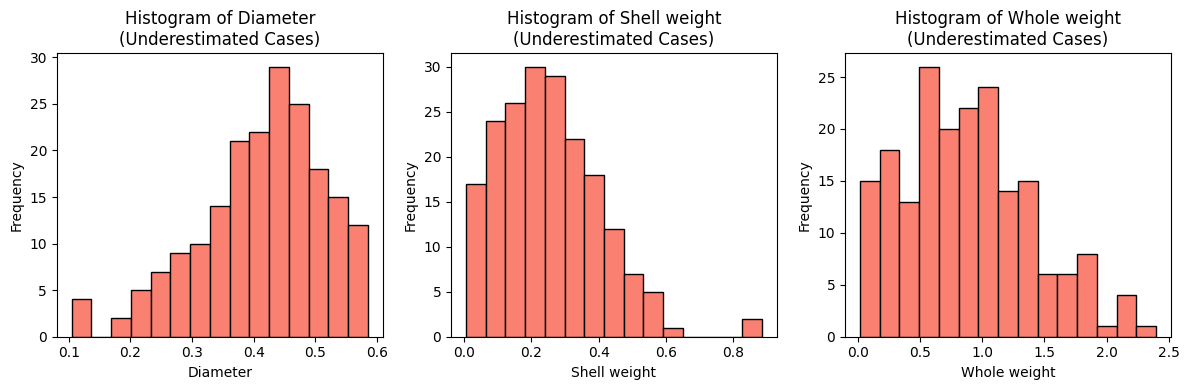

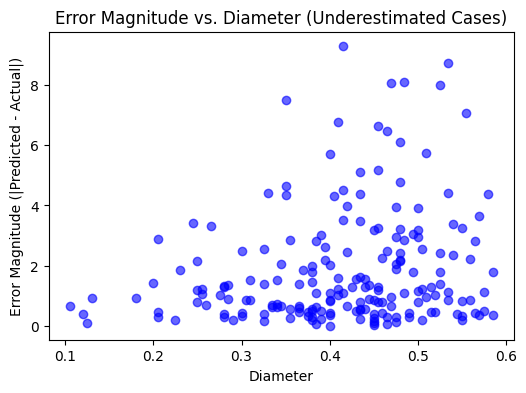

In [41]:

underestimated_cases = (y_val_pred_fold < y_val_fold).values

X_underestimated = X_val_df[underestimated_cases]
y_underestimated_actual = y_val_fold[underestimated_cases].values
y_underestimated_pred = y_val_pred_fold[underestimated_cases]

error_magnitude = np.abs(y_underestimated_actual - y_underestimated_pred)

plt.figure(figsize=(12, 4))
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(1, 3, i)
    plt.hist(X_underestimated[feature], bins=15, color="salmon", edgecolor="black")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.title(f"Histogram of {feature}\n(Underestimated Cases)")

plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 4))
plt.scatter(X_underestimated["Diameter"], error_magnitude, color="blue", alpha=0.6)
plt.xlabel("Diameter")
plt.ylabel("Error Magnitude (|Predicted - Actual|)")
plt.title("Error Magnitude vs. Diameter (Underestimated Cases)")
plt.show()


In [ ]:
final_models = pd.DataFrame({
    "Model Name": ["Linear Regression", "Polynomial Regression (Degree 2)", "KNN (k=10)"],
    "Hyperparameters": ["None", "Degree=2", "k=10"],
    "R²": [0.474, 0.515, 0.508],
    "MSE": [5.52, 5.08, 5.16],
    "MAE": [1.66, 1.58, 1.57]})

final_models

,Model Name,Hyperparameters,R²,MSE,MAE
0,Linear Regression,None,0.474,5.52,1.66
1,Polynomial Regression (Degree 2),Degree=2,0.515,5.08,1.58
2,KNN (k=10),k=10,0.508,5.16,1.57


In [ ]:
summary_file_path = "\Users\suden\Downloads\final_model_performance.csv"
final_models.to_csv(summary_file_path, index=False)

summary_file_path